In [1]:
from moabb.paradigms import LeftRightImagery
from moabb.datasets import *

sfreq=250
paradigm = LeftRightImagery(resample=sfreq)
datasets = [
    BNCI2014004()
]


BNCI2014004 has been renamed to BNCI2014_004. BNCI2014004 will be removed in version 1.1.
The dataset class name 'BNCI2014004' must be an abbreviation of its code 'BNCI2014-004'. See moabb.datasets.base.is_abbrev for more information.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter, ledoit_wolf_shrinkage
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler, FunctionTransformer
import warnings
from joblib import parallel_backend
from joblib import Parallel
from hoda.classification import SelectF
from sklearn.pipeline import make_pipeline
import tensorly as tl

clf = make_pipeline(
    SelectF(verbose=True),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=2,
    truncate=False,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=False,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    clf=clf,
)

In [8]:
import tensorly as tl
import pandas as pd
from hoda.tensorize import stf_tensor

select_infos = []
train_infos = []
for dataset in datasets:
    for subject in dataset.subject_list:
        epochs, labels, meta = paradigm.get_data(
            dataset=dataset, 
             subjects=[subject],
             return_epochs=True
        )
        for session in meta['session'].unique()[:1]:
            idc = meta['session'] == session
            epochs_ses = epochs[idc]
            labels_ses = labels[idc]
            meta_ses = meta[idc]

            X = epochs_ses.get_data()
            X = stf_tensor(X, sfreq=epochs.info['sfreq'], normalize=True,log=True )
            X = tl.tensor(X)
            y = labels_ses

            print(f'dataset={dataset.code} subject={subject} session={session}')
            bttda.fit(X,y, test=True)
            subj_select_info = pd.DataFrame(bttda.model_select_info_best_) 
            subj_select_info['dataset'] = dataset.code
            subj_select_info['subject'] = subject
            subj_select_info['session'] = session
            subj_train_info = pd.DataFrame(bttda.train_info_)
            subj_train_info['dataset'] = dataset.code
            subj_train_info['subject'] = subject
            subj_train_info['session'] = session
            select_infos.append(subj_select_info.reset_index())
            train_infos.append(subj_train_info.reset_index())
            # save
            select_info = pd.concat(select_infos, ignore_index=True)
            train_info = pd.concat(train_infos, ignore_index=True)
            select_info.to_csv('block_mi_select.csv')
            train_info.to_csv('block_mi_train.csv')


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
720 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: war

dataset=BNCI2014-004 subject=1 session=0train
Model selection block 1/2...

Trying rank (1, 1, 1)	Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
score: 0.9400
Trying rank (2, 2, 2)	Selected 3/8 features
Selected 2/8 features
Selected 2/8 features
Selected 2/8 features
Selected 2/8 features
score: 0.9800
Trying rank (3, 4, 4)	Selected 3/48 features
Selected 4/48 features
Selected 6/48 features
Selected 5/48 features
Selected 6/48 features
score: 0.9718
Trying rank (3, 8, 8)	Selected 5/192 features
Selected 10/192 features
Selected 12/192 features
Selected 9/192 features
Selected 7/192 features
score: 0.9713
Trying rank (3, 8, 16)	Selected 21/384 features
Selected 7/384 features
Selected 16/384 features
Selected 10/384 features
Selected 9/384 features
score: 0.9500
Trying rank (3, 8, 32)	Selected 14/768 features
Selected 15/768 features
Selected 14/768 features
Selected 15/768 features
Selected 25/768 features
score: 0.9611
T

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: war

dataset=BNCI2014-004 subject=2 session=0train
Model selection block 1/2...

Trying rank (1, 1, 1)	Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
score: 0.3376
Trying rank (2, 2, 2)	Selected 2/8 features
Selected 2/8 features
Selected 3/8 features
Selected 2/8 features
Selected 3/8 features
score: 0.5531
Trying rank (3, 4, 4)	Selected 6/48 features
Selected 7/48 features
Selected 6/48 features
Selected 10/48 features
Selected 5/48 features
score: 0.6180
Trying rank (3, 8, 8)	Selected 24/192 features
Selected 22/192 features
Selected 10/192 features
Selected 23/192 features
Selected 16/192 features
score: 0.6313
Trying rank (3, 8, 16)	Selected 19/384 features
Selected 29/384 features
Selected 23/384 features
Selected 36/384 features
Selected 27/384 features
score: 0.5280
Trying rank (3, 8, 32)	Selected 46/768 features
Selected 43/768 features
Selected 54/768 features
Selected 41/768 features
Selected 36/768 features
score: 0.

...

dataset=BNCI2014-004 subject=7 session=0train
Model selection block 1/2...

Trying rank (1, 1, 1)	Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
score: 0.6624
Trying rank (2, 2, 2)	Selected 2/8 features
Selected 2/8 features
Selected 2/8 features
Selected 3/8 features
Selected 2/8 features
score: 0.5644
Trying rank (3, 4, 4)	Selected 6/48 features
Selected 13/48 features
Selected 7/48 features
Selected 11/48 features
Selected 7/48 features
score: 0.7040
Trying rank (3, 8, 8)	Selected 16/192 features
Selected 7/192 features
Selected 8/192 features
Selected 19/192 features
Selected 11/192 features
score: 0.6031
Trying rank (3, 8, 16)	Selected 35/384 features
Selected 30/384 features
Selected 32/384 features
Selected 24/384 features
Selected 37/384 features
score: 0.6104
Trying rank (3, 8, 32)	Selected 42/768 features
Selected 42/768 features
Selected 41/768 features
Selected 21/768 features
Selected 48/768 features
score: 0.5

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: war

dataset=BNCI2014-004 subject=8 session=0train
Model selection block 1/2...

Trying rank (1, 1, 1)	Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
score: 0.6216
Trying rank (2, 2, 2)	Selected 3/8 features
Selected 2/8 features
Selected 3/8 features
Selected 3/8 features
Selected 2/8 features
score: 0.6984
Trying rank (3, 4, 4)	Selected 5/48 features
Selected 5/48 features
Selected 5/48 features
Selected 5/48 features
Selected 4/48 features
score: 0.5921
Trying rank (3, 8, 8)	Selected 10/192 features
Selected 11/192 features
Selected 17/192 features
Selected 23/192 features
Selected 8/192 features
score: 0.5450
Trying rank (3, 8, 16)	Selected 15/384 features
Selected 41/384 features
Selected 22/384 features
Selected 20/384 features
Selected 9/384 features
score: 0.5408
Trying rank (3, 8, 32)	Selected 29/768 features
Selected 58/768 features
Selected 26/768 features
Selected 63/768 features
Selected 28/768 features
score: 0.574

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: war

dataset=BNCI2014-004 subject=9 session=0train
Model selection block 1/2...

Trying rank (1, 1, 1)	Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
Selected 1/1 features
score: 0.6936
Trying rank (2, 2, 2)	Selected 2/8 features
Selected 2/8 features
Selected 2/8 features
Selected 2/8 features
Selected 2/8 features
score: 0.7453
Trying rank (3, 4, 4)	Selected 2/48 features
Selected 16/48 features
Selected 5/48 features
Selected 9/48 features
Selected 9/48 features
score: 0.6704
Trying rank (3, 8, 8)	Selected 17/192 features
Selected 9/192 features
Selected 9/192 features
Selected 28/192 features
Selected 16/192 features
score: 0.7344
Trying rank (3, 8, 16)	Selected 10/384 features
Selected 29/384 features
Selected 22/384 features
Selected 15/384 features
Selected 17/384 features
score: 0.5940
Trying rank (3, 8, 32)	Selected 40/768 features
Selected 21/768 features
Selected 5/768 features
Selected 36/768 features
Selected 28/768 features
score: 0.707

In [9]:
select_info

,block,rank,fold,train_score,val_score,n_features,test_score,dataset,subject,session
0,0,"(2, 2, 2)",0,0.994456,1.000000,8,0.839161,BNCI2014-004,1,0train
1,0,"(2, 2, 2)",1,0.998650,0.977778,8,0.881119,BNCI2014-004,1,0train
2,0,"(2, 2, 2)",2,0.993927,1.000000,8,0.839161,BNCI2014-004,1,0train
3,0,"(2, 2, 2)",3,0.999325,0.977778,8,0.881119,BNCI2014-004,1,0train
4,0,"(2, 2, 2)",4,0.991216,0.944444,8,0.804196,BNCI2014-004,1,0train
...,...,...,...,...,...,...,...,...,...,...
85,1,"(3, 8, 36)",0,0.988194,0.810000,872,0.600000,BNCI2014-004,9,0train
86,1,"(3, 8, 36)",1,0.971622,0.722222,872,0.507143,BNCI2014-004,9,0train
87,1,"(3, 8, 36)",2,0.965541,0.711111,872,0.650000,BNCI2014-004,9,0train
88,1,"(3, 8, 36)",3,0.975676,0.944444,872,0.600000,BNCI2014-004,9,0train


In [10]:
select_info

,block,rank,fold,train_score,val_score,n_features,test_score,dataset,subject,session
0,0,"(2, 2, 2)",0,0.994456,1.000000,8,0.839161,BNCI2014-004,1,0train
1,0,"(2, 2, 2)",1,0.998650,0.977778,8,0.881119,BNCI2014-004,1,0train
2,0,"(2, 2, 2)",2,0.993927,1.000000,8,0.839161,BNCI2014-004,1,0train
3,0,"(2, 2, 2)",3,0.999325,0.977778,8,0.881119,BNCI2014-004,1,0train
4,0,"(2, 2, 2)",4,0.991216,0.944444,8,0.804196,BNCI2014-004,1,0train
...,...,...,...,...,...,...,...,...,...,...
85,1,"(3, 8, 36)",0,0.988194,0.810000,872,0.600000,BNCI2014-004,9,0train
86,1,"(3, 8, 36)",1,0.971622,0.722222,872,0.507143,BNCI2014-004,9,0train
87,1,"(3, 8, 36)",2,0.965541,0.711111,872,0.650000,BNCI2014-004,9,0train
88,1,"(3, 8, 36)",3,0.975676,0.944444,872,0.600000,BNCI2014-004,9,0train


<Axes: xlabel='block', ylabel='value'>

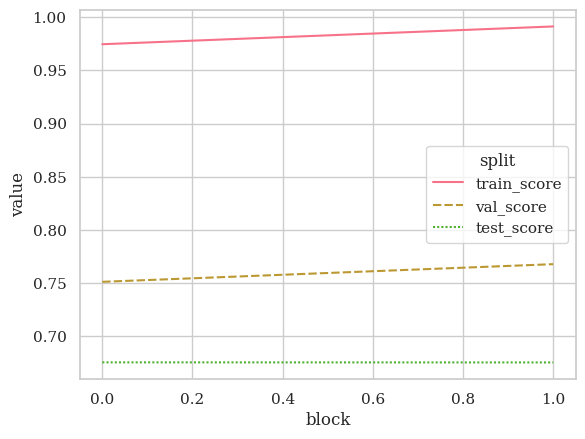

In [11]:
import seaborn as sns

idx = ['dataset', 'subject', 'session', 'block']
df = select_info.groupby(idx)[['train_score', 'val_score', 'test_score']].aggregate('mean')
df = df.melt(var_name='split', ignore_index=False)
df = df.reset_index()
sns.lineplot(data=df, x='block', y='value', hue='split', style='split', errorbar=None)

In [12]:
train_info.to_csv('block_mi_train.csv')
train_info

,index,block,rank,F_tr,F_rt,log_loss,mse,nmse,dataset,subject,session
0,0,1,"(2, 2, 2)",0.008476,0.040237,0.142989,0.977882,0.977882,BNCI2014-004,1,0train
1,1,2,"(3, 8, 32)",0.000170,0.255340,0.000411,0.191696,0.191696,BNCI2014-004,1,0train
2,0,1,"(3, 8, 8)",0.000347,0.090922,0.045323,0.856401,0.856401,BNCI2014-004,2,0train
3,1,2,"(3, 8, 8)",0.000349,0.162063,0.000437,0.778521,0.778521,BNCI2014-004,2,0train
4,0,1,"(2, 2, 2)",0.002515,0.010804,0.462893,0.987169,0.987169,BNCI2014-004,3,0train
5,1,2,"(1, 1, 1)",0.003228,0.028675,0.239470,0.980814,0.980814,BNCI2014-004,3,0train
6,0,1,"(1, 1, 1)",0.030068,0.059134,0.058042,0.982675,0.982675,BNCI2014-004,4,0train
7,1,2,"(3, 8, 32)",0.000143,0.230189,0.000002,0.227945,0.227945,BNCI2014-004,4,0train
8,0,1,"(3, 8, 32)",0.000122,0.169849,0.000717,0.216963,0.216963,BNCI2014-004,5,0train
9,1,2,"(2, 2, 2)",0.000122,0.171620,0.001044,0.209160,0.209160,BNCI2014-004,5,0train


<Axes: xlabel='block', ylabel='nmse'>

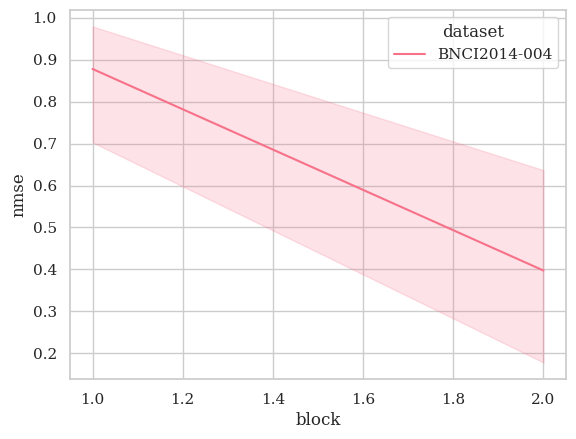

In [13]:
df = train_info.groupby(idx)
df = df['nmse'].aggregate('mean')
df = df.reset_index()
sns.lineplot(data=df, x='block',y='nmse', hue='dataset')